In [2]:
import sys, os
REPO_PATH = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
if REPO_PATH not in sys.path:
    sys.path.insert(0, REPO_PATH)
print(f"REPO_PATH: {REPO_PATH}")  # debug

REPO_PATH: c:\Users\Aymen ich\Projects\ML_pipeline\flipkart_sentiments_pfa


# Flipkart Reviews — Analyse Exploratoire (EDA)
## Auteur : Ihssane Moutchou et Aymen Ichqarrane | Projet de Fin d'Année
## Objectif : Explorer le dataset, labelliser les sentiments,
## visualiser la distribution et les patterns lexicaux.

Étape 1 : Premier contact avec les données !

Combien avons-nous d'avis ? À quoi ressemble le texte brut ?

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [10]:
df = pd.read_csv(os.path.join(REPO_PATH, 'data', 'flipkart_data.csv'))
display(df.head())
display(df.info())
display(df.head())
display(df.info())

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


<class 'pandas.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  9976 non-null   str  
 1   rating  9976 non-null   int64
dtypes: int64(1), str(1)
memory usage: 156.0 KB


None

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


<class 'pandas.DataFrame'>
RangeIndex: 9976 entries, 0 to 9975
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  9976 non-null   str  
 1   rating  9976 non-null   int64
dtypes: int64(1), str(1)
memory usage: 156.0 KB


None

Étape 2 : On transforme les reviews De la note au Sentiment (Création de notre "Target")

Un modèle de NLP préfère deviner des classes plutôt que des chiffres. On transforme donc nos étoiles (1 à 5) en émotions claires : **POSITIF, NEUTRE ou NEGATIF**.

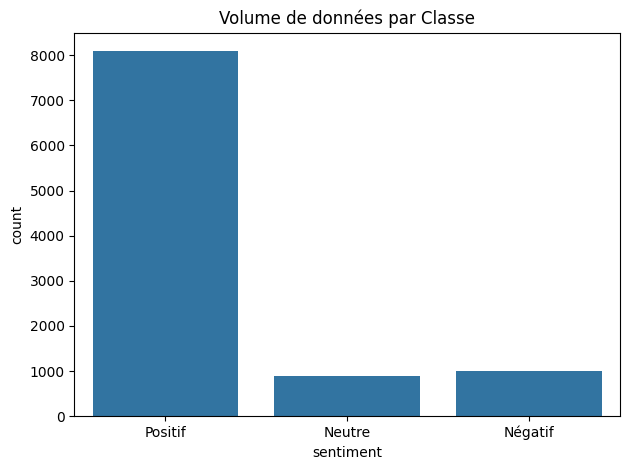

sentiment
Positif    81.104651
Négatif    10.034082
Neutre      8.861267
Name: proportion, dtype: float64


In [11]:
# Fonction pour labéliser
def get_sentiment(rating):
    if rating >= 4: return 'Positif'
    elif rating == 3: return 'Neutre'
    else: return 'Négatif'

df['sentiment'] = df['rating'].apply(get_sentiment)

# Visualisation du volume par classe
sns.countplot(data=df, x='sentiment', order=['Positif', 'Neutre', 'Négatif'])
plt.title("Volume de données par Classe")
plt.tight_layout()
plt.show()

print(df['sentiment'].value_counts(normalize=True) * 100)

Étape 3 : Prise des mensurations de nos textes

On va créer deux nouvelles colonnes pour compter les **caractères** et les **mots**.
Cela sera hyper utile à la Phase 2 pour repérer les "spams" (avis d'un seul mot) ou définir la taille maximale de lecture du modèle.

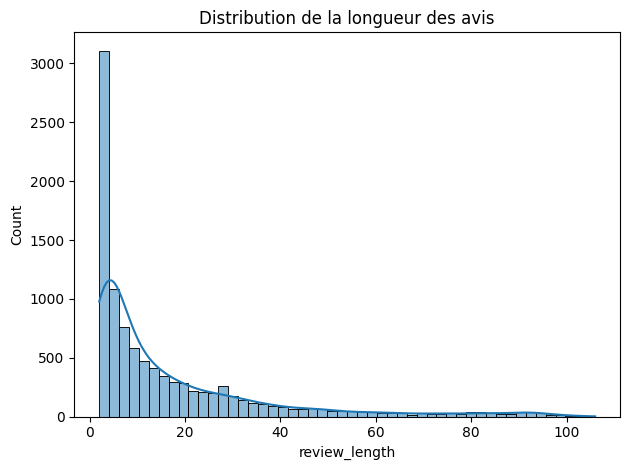

Longueur moyenne par sentiment :
sentiment
Neutre     22.631222
Négatif    18.236763
Positif    16.004697
Name: review_length, dtype: float64


In [12]:
# Calcul du nombre de mots par avis
df['review_length'] = df['review'].astype(str).apply(lambda x: len(x.split()))

sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Distribution de la longueur des avis')
plt.tight_layout()
plt.show()

print("Longueur moyenne par sentiment :")
print(df.groupby('sentiment')['review_length'].mean())

Détection de la langue dominante de notre dataset flipkart

In [15]:
from langdetect import detect

# Fonction sécurisée pour détecter la langue (gère les textes vides)
def detect_language(text):
    try:
        return detect(str(text))
    except:
        return 'unknown'

# On teste sur un échantillon pour aller plus vite
df['lang'] = df['review'].sample(1000).apply(detect_language)
print(df['lang'].value_counts())

lang
en    816
ro     53
so     28
id     21
af     16
ca     14
de     12
cs      7
fr      6
pl      5
tr      3
sw      3
et      3
da      2
no      2
es      2
cy      1
sq      1
sv      1
tl      1
it      1
hu      1
sl      1
Name: count, dtype: int64


Étape 4 : La "météo" du vocabulaire (Wordclouds)
Quels sont les mots qui reviennent le plus quand on est ravi, déçu ou mitigé ? Cette étape visuelle

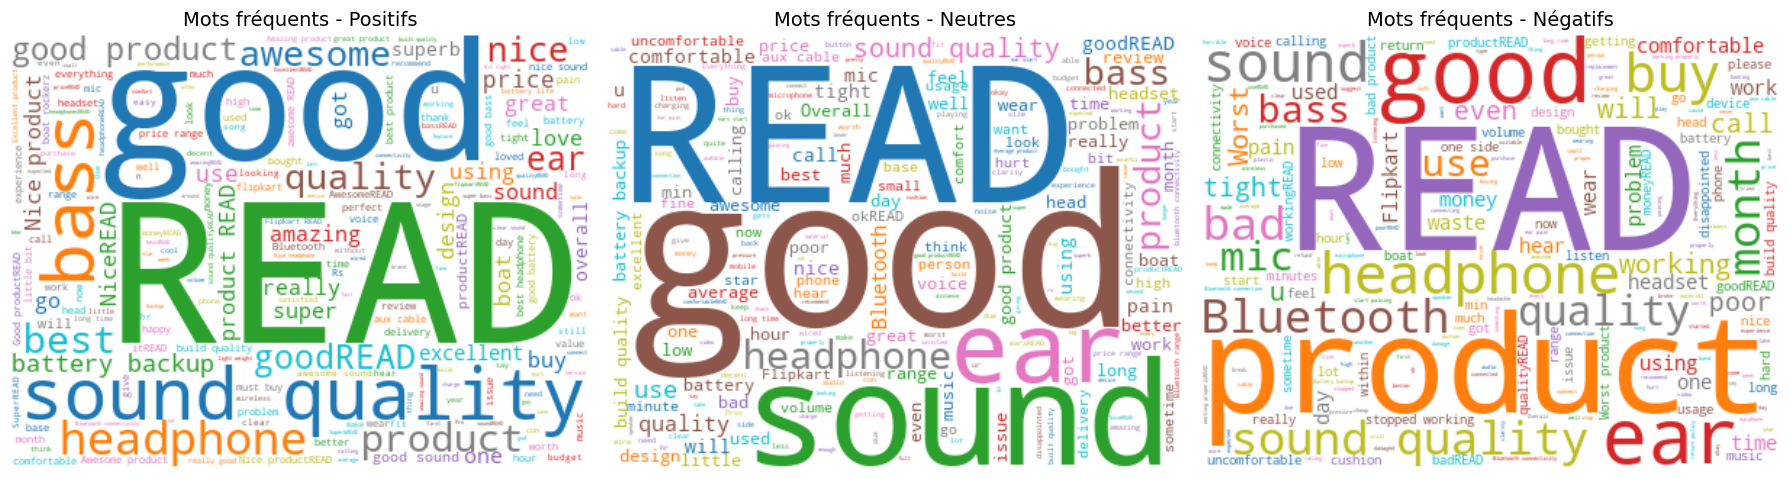

In [17]:
from wordcloud import WordCloud

# 1. Séparer le texte selon le sentiment
text_pos = " ".join(df[df['sentiment'] == 'Positif']['review'].astype(str))
text_neu = " ".join(df[df['sentiment'] == 'Neutre']['review'].astype(str))
text_neg = " ".join(df[df['sentiment'] == 'Négatif']['review'].astype(str))

# 2. Créer une fonction pour éviter de répéter le code
def plot_wordcloud(text, title, position):
    wordcloud = WordCloud(width=400, height=300, background_color='white', colormap='tab10').generate(text)
    plt.subplot(1, 3, position) # 1 ligne, 3 colonnes
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=14)
    plt.axis('off')

# 3. Afficher les 3 nuages côte à côte
plt.figure(figsize=(18, 5))

plot_wordcloud(text_pos, 'Mots fréquents - Positifs', 1)
plot_wordcloud(text_neu, 'Mots fréquents - Neutres', 2)
plot_wordcloud(text_neg, 'Mots fréquents - Négatifs', 3)

plt.tight_layout()
plt.show()

In [18]:
# Création de la colonne sentiment
df['sentiment'] = df['rating'].apply(get_sentiment)

# 2. Création de la colonne 'review_len' (Nombre total de caractères)
df['review_len'] = df['review'].astype(str).apply(len)

# 3. Création de la colonne 'word_count' (Nombre de mots)
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

# 4. Affichage pour vérifier
display(df.head())

,review,rating,sentiment,review_length,lang,review_len,word_count
0,It was nice produt. I like it's design a lot. ...,5,Positif,18,NaN,98,18
1,awesome sound....very pretty to see this nd th...,5,Positif,24,NaN,134,24
2,awesome sound quality. pros 7-8 hrs of battery...,4,Positif,80,NaN,499,80
3,I think it is such a good product not only as ...,5,Positif,81,NaN,405,81
4,awesome bass sound quality very good bettary l...,5,Positif,24,NaN,144,24


Étape 5 : L'emballage cadeau pour la Phase 2 !
Notre mission d'exploration est terminée. Le diagnostic est posé et le dataset est enrichi.

### Synthèse Finale des Statistiques

In [19]:
print(f"Total d'avis dans le dataset : {len(df)}\n")

print("Distribution des sentiments :")
print(df['sentiment'].value_counts(normalize=True) * 100)

print("\nLongueur moyenne des avis (en mots) par sentiment :")
print(df.groupby('sentiment')['review_length'].mean())

print(f"\nLongueur moyenne globale des avis (en mots) : {df['review_length'].mean():.2f}")
print(f"Longueur minimale des avis (en mots) : {df['review_length'].min()}")
print(f"Longueur maximale des avis (en mots) : {df['review_length'].max()}")

Total d'avis dans le dataset : 9976

Distribution des sentiments :
sentiment
Positif    81.104651
Négatif    10.034082
Neutre      8.861267
Name: proportion, dtype: float64

Longueur moyenne des avis (en mots) par sentiment :
sentiment
Neutre     22.631222
Négatif    18.236763
Positif    16.004697
Name: review_length, dtype: float64

Longueur moyenne globale des avis (en mots) : 16.82
Longueur minimale des avis (en mots) : 2
Longueur maximale des avis (en mots) : 106


In [20]:
# 5. Export du fichier final pour ihssano
df.to_csv('flipkart_data_with_sentiment.csv', index=False)
print("Fichier 'flipkart_data_with_sentiment.csv' généré avec succès ! Prêt pour la phase 2.")

Fichier 'flipkart_data_with_sentiment.csv' généré avec succès ! Prêt pour la phase 2.
